# Notebook说明
该Notebook文件为卒中分类模型构建，输入平扫CT影像，系统给出该影像是三分类结果（正常、出血性卒中、缺血性卒中）以及概率值。
该模型运用卷积MoE以及Vision Transformer混合架构，使用卷积CNN进行局部特征提取和分析，采用Vision Transformer进行全局分析。
## 代码内容：
* 硬件检测与环境配置
* 准备和预处理训练数据
* 构建和设置模型
* 训练和初步评估模型

检测系统配置

In [1]:
import os
print('CPU可用核心数:',os.cpu_count())

CPU可用核心数: 52


In [2]:
#获取GPU可用性
import tensorflow as tf
print('GPU可用性:',tf.test.is_gpu_available())
print("可用GPU数: ", len(tf.config.experimental.list_physical_devices('GPU')))

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU可用性: True
可用GPU数:  2


2025-08-27 14:18:12.064820: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-27 14:18:14.455023: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /device:GPU:0 with 30980 MB memory:  -> device: 0, name: Tesla V100-PCIE-32GB, pci bus id: 0000:67:02.0, compute capability: 7.0
2025-08-27 14:18:14.456218: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /device:GPU:1 with 30980 MB memory:  -> device: 1, name: Tesla V100-PCIE-32GB, pci bus id: 0000:67:04.0, compute capability: 7.0


读取图像文件地址

In [3]:
#读取文件地址
import pandas as pd
ImageFile=pd.read_csv('/root/StrokeDataset/ImageFiles.csv')
ImageFile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6650 entries, 0 to 6649
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   6650 non-null   int64 
 1   Iamge Path   6650 non-null   object
 2   Iamge Label  6650 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 156.0+ KB


In [4]:
#查看数据标签分布
import matplotlib.pyplot as plt
from collections import Counter
def EveluateLabel(labellist):
    print('样本标签统计:',Counter(labellist))
    hist=plt.figure(dpi=72)
    plt.hist(labellist)
    plt.show()

样本标签统计: Counter({0: 4427, 1: 1130, 2: 1093})


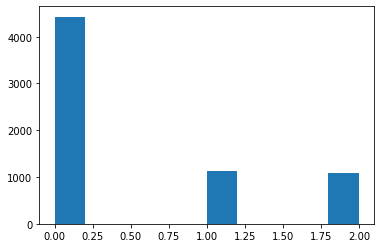

In [5]:
EveluateLabel(labellist=ImageFile.loc[:,'Iamge Label'])

In [6]:
#读取并可视化PNG格式数据
import cv2
import matplotlib.pyplot as plt
def ShowPNGImage(norpath,quexuepath,chuxuepath):
    NormalImage=cv2.imread(norpath)    #正常组
    QueXueImage=cv2.imread(quexuepath)   #缺血组
    ChuXueImage=cv2.imread(chuxuepath)   #出血组
    PNGFigure=plt.figure(figsize=(15,5),dpi=300)
    plt.subplot(1,3,1)
    plt.title('Normal Image')
    plt.imshow(NormalImage)
    plt.subplot(1,3,2)
    plt.title('Ischemia Image')
    plt.imshow(QueXueImage)
    plt.subplot(1,3,3)
    plt.title('Bleeding Image')
    plt.imshow(ChuXueImage)
    plt.show()

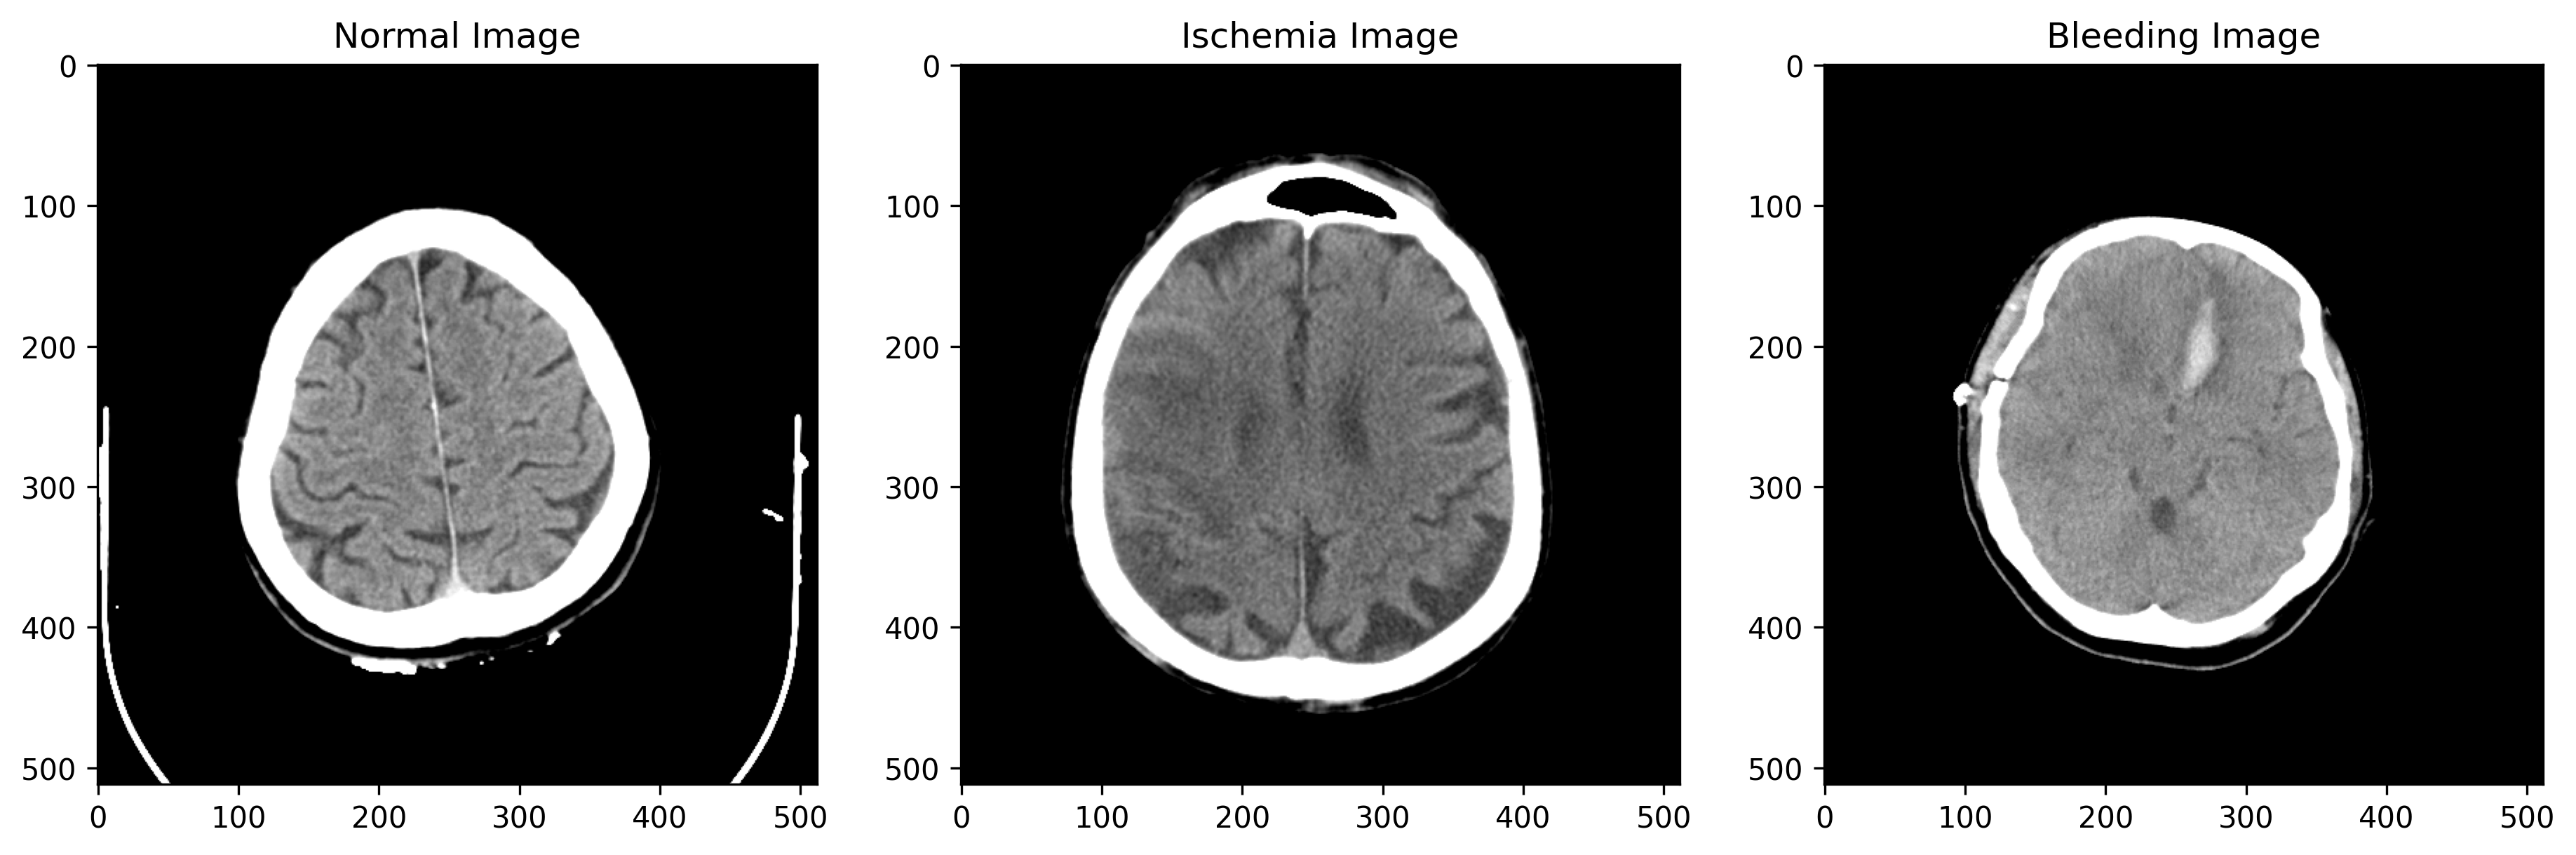

In [7]:
ShowPNGImage(norpath='/root/StrokeDataset/Normal/PNG/10000.png',quexuepath='/root/StrokeDataset/Ischemia/PNG/10003.png',
             chuxuepath='/root/StrokeDataset/Bleeding/PNG/10002.png')

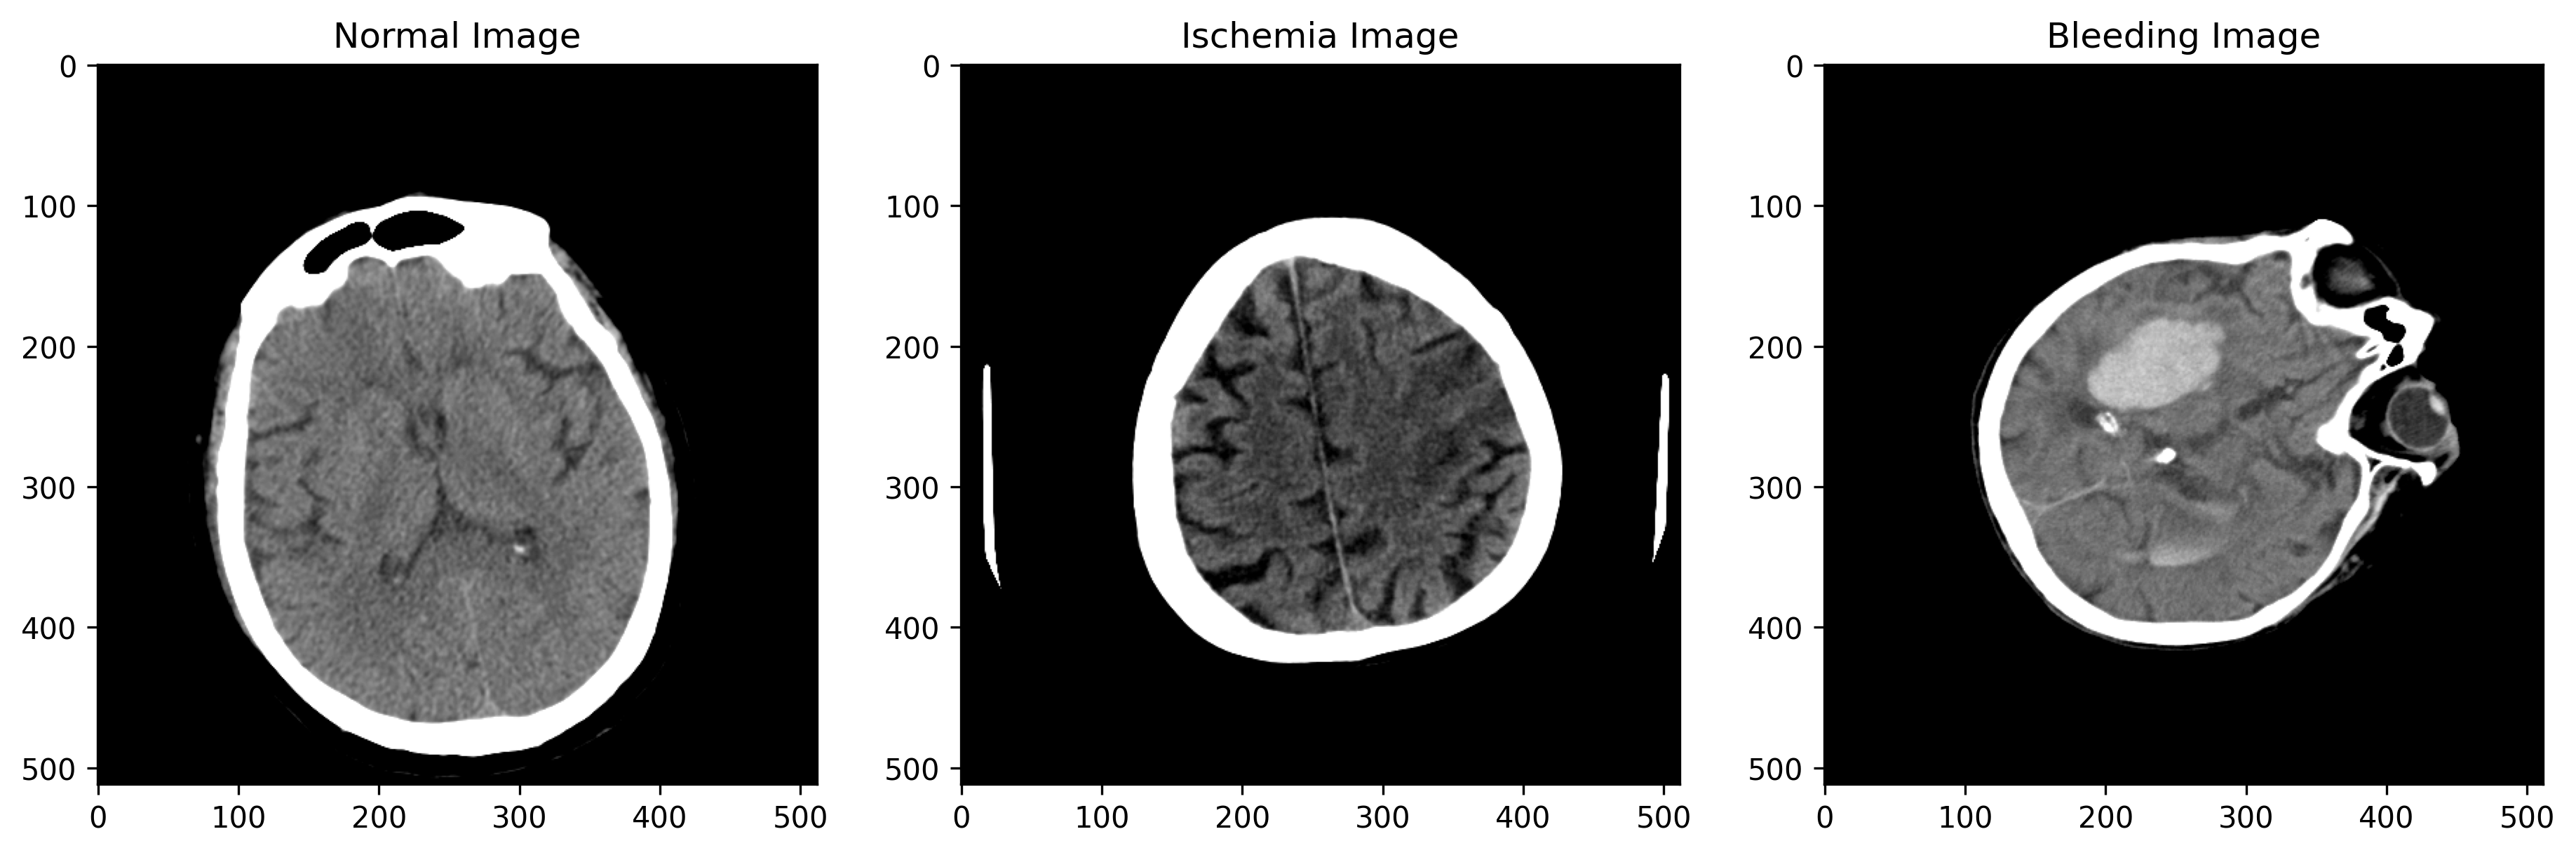

In [8]:
ShowPNGImage(norpath='/root/StrokeDataset/Normal/PNG/10001.png',quexuepath='/root/StrokeDataset/Ischemia/PNG/10017.png',
             chuxuepath='/root/StrokeDataset/Bleeding/PNG/10033.png')

构建数据输入流

In [9]:
#分割数据集+分层抽样
from sklearn.model_selection import train_test_split
TrainPath,SplitPath,TrainLabel,SplitLabel=train_test_split(ImageFile.loc[:,'Iamge Path'],ImageFile.loc[:,'Iamge Label'],train_size=0.7,
                                                           stratify=ImageFile.loc[:,'Iamge Label'],random_state=2025)
ValidPath,TestPath,ValidLabel,TestLabel=train_test_split(SplitPath,SplitLabel,train_size=0.5,stratify=SplitLabel,random_state=2025)
print('训练集地址:{0},验证集地址:{1},测试集地址:{2}'.format(len(TrainPath),len(ValidPath),len(TestPath)))
print('训练集标签:{0},验证集标签:{1},测试集标签:{2}'.format(len(TrainLabel),len(ValidLabel),len(TestLabel)))

训练集地址:4655,验证集地址:997,测试集地址:998
训练集标签:4655,验证集标签:997,测试集标签:998


样本标签统计: Counter({0: 3099, 1: 791, 2: 765})


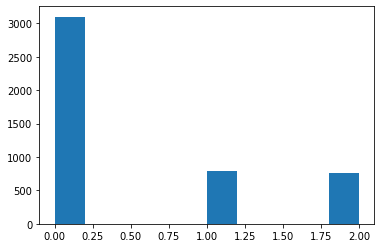

In [10]:
#训练集标签分布
EveluateLabel(labellist=TrainLabel)

样本标签统计: Counter({0: 664, 1: 169, 2: 164})


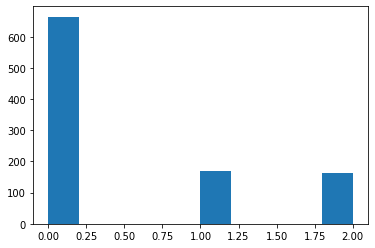

In [11]:
#验证集标签分布
EveluateLabel(labellist=ValidLabel)

样本标签统计: Counter({0: 664, 1: 170, 2: 164})


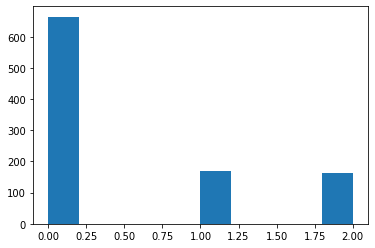

In [12]:
#测试集标签分布
EveluateLabel(labellist=TestLabel)

In [13]:
#编写数据读取函数
import tensorflow as tf
def ReadImageData(path,ImageLabel):
        image_io=tf.io.read_file(path)    #读取文件
        image_data=tf.image.decode_png(image_io,channels=3)    #解码图像数据
        image_datare=tf.image.resize(image_data,(512,512))
        image_normal=tf.cast(image_datare, tf.float32)/255.0
        return (image_normal,ImageLabel)

In [14]:
#使用文件路径方法批量读取数据
#训练集
FilePathDataset_Train=tf.data.Dataset.from_tensor_slices((TrainPath,TrainLabel)).repeat(2)    #文件路径数据集
ImageDataset_Train=FilePathDataset_Train.shuffle(buffer_size=1000,seed=2025).map(ReadImageData,num_parallel_calls=tf.data.experimental.AUTOTUNE)    #获取文件路径
ImageDataset_Train=ImageDataset_Train.batch(batch_size=50).prefetch(tf.data.experimental.AUTOTUNE)
#验证集
FilePathDataset_Valid=tf.data.Dataset.from_tensor_slices((ValidPath,ValidLabel)).repeat(2)    #文件路径数据集
ImageDataset_Valid=FilePathDataset_Valid.shuffle(buffer_size=1000,seed=2025).map(ReadImageData,num_parallel_calls=tf.data.experimental.AUTOTUNE)    #获取文件路径
ImageDataset_Valid=ImageDataset_Valid.batch(batch_size=50).prefetch(tf.data.experimental.AUTOTUNE)
#测试集
FilePathDataset_Test=tf.data.Dataset.from_tensor_slices((TestPath,TestLabel)).repeat(2)    #文件路径数据集
ImageDataset_Test=FilePathDataset_Test.shuffle(buffer_size=1000,seed=2025).map(ReadImageData,num_parallel_calls=tf.data.experimental.AUTOTUNE)    #获取文件路径
ImageDataset_Test=ImageDataset_Test.batch(batch_size=50).prefetch(tf.data.experimental.AUTOTUNE)

2025-08-27 14:18:52.809267: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 30980 MB memory:  -> device: 0, name: Tesla V100-PCIE-32GB, pci bus id: 0000:67:02.0, compute capability: 7.0
2025-08-27 14:18:52.809873: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 30980 MB memory:  -> device: 1, name: Tesla V100-PCIE-32GB, pci bus id: 0000:67:04.0, compute capability: 7.0


构建模型

卷积MOE模块
输入数据尺寸[batch,512,512,3]
输出数据尺寸[batch,56,896]

In [15]:
#构建卷积神经网络
from tensorflow import keras
#Input shape[512,512,3];Output shape[14,14,64]
def ConvD2DModel(activation):
    EncoderImage=keras.models.Sequential([])
    EncoderImage.add(keras.layers.Input(shape=[512,512,3]))
    #Conv2D Blocks1
    EncoderImage.add(keras.layers.Conv2D(filters=9,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=9,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=None,padding='valid',data_format='channels_last'))
    #Conv2D Blocks2 
    EncoderImage.add(keras.layers.Conv2D(filters=18,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=18,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=None,padding='valid',data_format='channels_last'))
    #Conv2D Blocks3 
    EncoderImage.add(keras.layers.Conv2D(filters=36,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=36,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=None,padding='valid',data_format='channels_last'))
    #Conv2D Blocks4
    EncoderImage.add(keras.layers.Conv2D(filters=64,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=64,kernel_size=(3,3),strides=(2,2),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=(2,2),padding='valid',data_format='channels_last',name='Output_Encoder'))
    return EncoderImage

In [16]:
#定义卷积路由器
class ConvidRounter(keras.layers.Layer):
    def __init__(self,ImageShape,**kwargs):
        super().__init__(**kwargs)
        #卷积Router参数
        self.ImageShape=ImageShape    #输入图像大小
        #定义卷积Router模块
        self.InputLayer = keras.layers.InputLayer(input_shape=self.ImageShape)
        self.Conv2DInput=keras.layers.Conv2D(filters=20,kernel_size=(3,3),strides=(2,2),activation='relu',padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',
                                             bias_initializer='zeros',input_shape=self.ImageShape)
        self.Conv2D2=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.Conv2D3=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.MaxPooling=keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', data_format='channels_last')
        self.Conv2D4=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.Conv2D5=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.Flatten=keras.layers.Flatten()
        self.Dense=keras.layers.Dense(units=128, activation='relu',kernel_initializer='lecun_normal',kernel_regularizer=None,
                   kernel_constraint=None)
        self.Problity=keras.layers.Dense(units=4,activation='softmax',kernel_initializer='lecun_normal',kernel_regularizer=None,
                   kernel_constraint=None)
    def call(self,inputs):
        Input=self.InputLayer(inputs)
        Conv2DOut1=self.Conv2DInput(Input)    #卷积模块
        Conv2DOut2=self.Conv2D2(Conv2DOut1)
        Conv2DOut3=self.Conv2D3(Conv2DOut2)
        MaxPool1=self.MaxPooling(Conv2DOut3)
        Conv2DOut4=self.Conv2D4(MaxPool1)
        Conv2DOut5=self.Conv2D5(Conv2DOut4)
        MaxPool2=self.MaxPooling(Conv2DOut5)    #Outshape[3,5,20]
        FlattenOut=self.Flatten(MaxPool2)
        DenseOut1=self.Dense(FlattenOut)
        ProbilityOut1=self.Problity(DenseOut1)    #Outshape[batch,4]
        return ProbilityOut1
    def compute_output_shape(self):
        return tf.TensorShape([-1,4])
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'ImageShape':self.ImageShape}

In [17]:
#基于MoE架构构建卷积MoE层
import tensorflow
from tensorflow import keras
class ConvidMoELayer(keras.layers.Layer):
    #input shape[batch,512,512,3]--> output shape[batch,56,896]
    def __init__(self,Runter,Expoer1,Expoer2,Expoer3,Expoer4,**kwargs):
        super().__init__(**kwargs)
        self.Runter=Runter    #定义路由器模型
        #专家模型
        self.ConvidExpert1=Expoer1
        self.ConvidExpert2=Expoer2
        self.ConvidExpert3=Expoer3
        self.ConvidExpert4=Expoer4
    def call(self,inputs):
        #路由器模型输出概率
        RouterProblityOut=self.Runter(inputs)
        #计算专家模型输出 输入数据[512, 512,3]
        #Expert1
        Expert1Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #Expert2
        Expert2Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #Expert3
        Expert3Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #Expert4
        Expert4Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #整合专家模型输出结果
        ExpertOut=[Expert1Out,Expert2Out,Expert3Out,Expert4Out]    #输出[batch_size, 14, 14，64]
        # 将路由器输出的概率值扩展为与专家输出相同的维度
        router_output_expanded=tf.expand_dims(RouterProblityOut, axis=1)  # [batch_size, 1, 4]
        router_output_expanded=tf.expand_dims(router_output_expanded, axis=1)  # [batch_size, 1, 1, 4]
        router_output_expanded=tf.tile(router_output_expanded, [1, 14, 14, 1])  # [batch_size, 14, 14, 4]
        #将专家输出与路由器概率相乘
        weighted_expert_outputs=[expert_output * router_output_expanded[:, :, :, i:i+1] for i, expert_output in enumerate(ExpertOut)]
        # 展开通道维度并拼接
        reshaped_outputs = [tf.reshape(output, [-1, 14, 896]) for output in weighted_expert_outputs]  # 形状为[batch_size, 14,896]
        MoEOut= tf.concat(reshaped_outputs, axis=1)  # 形状为[batch_size,56,896]
        return MoEOut
    def compute_output_shape(self):
        return tf.TensorShape([56,896])
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'Runter':self.Runter,'Expoer1':self.ConvidExpert1,'Expoer2':self.ConvidExpert2,'Expoer3':self.ConvidExpert3,
                'Expoer4':self.ConvidExpert4}

构建Vision Transformer

图像补丁化（Patch Embedding）
将输入图像分割为固定大小的非重叠补丁，通过线性变换将每个补丁映射到高维向量。
设输入图像尺寸为 H×W×C（ 512×512×3），补丁大小为 P×P（ 16×16），
补丁数量为: N=(H/P)×(W/P)32×32=1024。
每个补丁展平后维度为:P×P×C（ 16×16×3=768），
通过线性层（权重矩阵 W)映射为维度dmodel的向量.

In [18]:
#Patch Embedding
class PatchEmbedding(keras.layers.Layer):
    def __init__(self, patch_size, embed_dim, **kwargs):
        super().__init__(** kwargs)
        self.patch_size=patch_size  # 补丁大小: 32x32
        self.embed_dim=embed_dim    # 嵌入维度:896
        #卷积层实现补丁提取+线性嵌入（等价于分割补丁后做线性变换）
        self.PatchLinear=keras.layers.Conv2D(filters=self.embed_dim,kernel_size=self.patch_size,strides=self.patch_size,
                                        activation=None,name="patch_projection")   #Output shape:[32,32,56]
        # 类别令牌（可学习）
        self.class_token = self.add_weight(shape=(1, 1, self.embed_dim),initializer="random_normal",trainable=True,
                                           name="class_token")

    def call(self, inputs):
        # 输入: [batch_size, 512, 512, 3]
        batch_size=tf.shape(inputs)[0]
        # 1. 提取补丁并嵌入: [batch_size, 16, 16,896]（16=512/31）
        Patch=self.PatchLinear(inputs)  # 卷积等价于分割+线性映射
        # 2. 展平为序列: [batch_size,256,896]（256=16x16）
        FlattenPatch=keras.layers.Reshape((-1, self.embed_dim))(Patch)
        # 3. 添加类别令牌: [batch_size,257,896]（256+1）
        class_tokens=tf.broadcast_to(self.class_token, (batch_size, 1, self.embed_dim))
        PatchEmbedding=tf.concat([class_tokens,FlattenPatch], axis=1)
        return PatchEmbedding
    def compute_output_shape(self):
        return tf.TensorShape([257,896])
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'patch_size':self.patch_size, 'embed_dim':self.embed_dim}

位置编码（Positional Encoding）
由于 Transformer 不具备时序感知能力，需为每个补丁向量添加位置信息。
ViT 采用可学习的位置编码：定义位置向量 
Pos(i)∈Rdmodel（与补丁向量同维度)[batch,1025,55]

In [19]:
#位置编码
class PositionalEncoding(keras.layers.Layer):
    def __init__(self,seq_len,embed_dim, **kwargs):
        super().__init__(** kwargs)
        self.seq_len=seq_len    #序列长度（257）
        self.embed_dim=embed_dim    #嵌入维度（896）
        # 可学习的位置编码
        self.pos_embed=self.add_weight(shape=(1, self.seq_len,self.embed_dim),initializer="random_normal",
            trainable=True,name="positional_encoding")
    def call(self, inputs):
        # 输入: [batch_size, seq_len, embed_dim]
        PosEmbedding=tf.add(inputs,self.pos_embed)    # 加位置编码
        return  PosEmbedding
    def compute_output_shape(self):
        return tf.TensorShape([257,896])
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'seq_len':self.seq_len,'embed_dim':self.embed_dim}

构建Transformer Encoder
Transformer由MAS和FFN模块构成；
MSA包含多头自注意力以及残差连接
FFN由MLP以及残差连接构成
输入：[batch,56,1025],输出：[batch,56,1025]

In [20]:
#构建SwiGLU单元
class SwiGLU(keras.layers.Layer):
    def __init__(self,input_dim,width_dim,deep_dim,**kwargs):
        #input [batchsize,input_dim,width_dim]"
         #Output [batchsize,input_dim,width_dim]
        super().__init__(**kwargs)
        self.input_dim=input_dim    #输入维度257
        self.width_dim=width_dim    #输出维度896
        self.deep_dim=deep_dim   #升维维度3584
        self.linear1=keras.layers.Dense(input_dim=self.width_dim,units=self.deep_dim,activation=None)    #[batch,257,3584]
        self.linear2=keras.layers.Dense(input_dim=self.width_dim,units=self.deep_dim,activation=None)    #[batch,257,3584]
        self.linear3=keras.layers.Dense(input_dim=self.deep_dim,units=self.width_dim,activation=None)    #[batch,257,896]
    def call(self,inputs):
        x1=self.linear1(inputs)
        x2=self.linear2(inputs)
        swish_x1=tf.nn.swish(x1)
        SwishGLU=swish_x1*x2
        Output=self.linear3(SwishGLU)
        return Output
    def compute_output_shape(self):    #规范输出维度
        return tf.TensorShape([self.input_dim,self.width_dim])    #[257,896]
    def get_config(self):
        Base_config=super().get_config()
        return {**Base_config,'input_dim':self.input_dim,'width_dim':self.width_dim,'deep_dim':self.deep_dim}

In [21]:
#构建TransformerEncoder
class TransFormerEncoder(keras.layers.Layer):
    def __init__(self,hight_dim,key_dim,heads,SwiGLU,**kwargs):
        #input shape[batch,257,896]---> Output shape[batch,257,896]
        super().__init__(**kwargs)
        self.heads=heads    #自注意力头
        self.hight_dim=hight_dim    #序列长度
        self.key_dim=key_dim    #嵌入维度
        self.SwiGLU=SwiGLU    #SwiGLU单元
        self.LayerNorm=keras.layers.LayerNormalization(epsilon=1e-6)  # 层归一化
        self.MutliHeadAttention=keras.layers.MultiHeadAttention(num_heads=self.heads,key_dim=self.key_dim,value_dim=self.key_dim,dropout=0.5)    #多头自注意力
        self.AddLayer=keras.layers.Add() 
    def call(self,inputs):
        LayerNorm1=self.LayerNorm(inputs)    #层归一化
        MAS=self.MutliHeadAttention(query=LayerNorm1,value=LayerNorm1,key=LayerNorm1,return_attention_scores=False,attention_mask=None)    #计算MAS
        Output1=self.AddLayer([MAS,LayerNorm1])    #残差连接
        LayerNorm2=self.LayerNorm(Output1)    #层归一化
        OutputSwiGLU=self.SwiGLU(LayerNorm2)    #SwiGLU
        Output2=self.AddLayer([OutputSwiGLU,LayerNorm2])    #残差连接
        return Output2
    def compute_output_shape(self):    #规范输出维度
        return tf.TensorShape([self.hight_dim,self.key_dim])
    def get_config(self):
        Base_config=super().get_config()
        return {**Base_config,'hight_dim':self.hight_dim,'key_dim':self.key_dim,'heads':self.heads,'SwiGLU':self.SwiGLU}

In [22]:
#构建Light Attention-Linear Attention
class LinearAttention(keras.layers.Layer):
    #input shape[batch,57,896]--->[batch,57,896]
    def __init__(self, heigh, width,channels,in_channels, kernel_fn=tf.nn.relu, **kwargs):
        super().__init__(** kwargs)
        self.heigh=heigh    #高度
        self.width= width    #宽度
        self.channels=channels    #通道数
        self.in_channels=in_channels    #输入通道数
        self.kernel_fn=kernel_fn  # 核函数（如ReLU、exp等）
        self.eps = 1e-6  # 防止除零错误
        # Q、K、V的投影层（1x1卷积实现通道映射）
        self.q_proj=keras.layers.Conv2D(filters=self.in_channels, kernel_size=1, use_bias=False)
        self.k_proj=keras.layers.Conv2D(filters=self.in_channels, kernel_size=1, use_bias=False)
        self.v_proj=keras.layers.Conv2D(filters=self.in_channels, kernel_size=1, use_bias=False)
        # 输出投影层（保持通道数一致）
        self.out_proj = keras.layers.Conv2D(filters=in_channels, kernel_size=1)
    def call(self, inputs):
        # 输入形状：[batch,57,896,1]
        n=self.heigh*self.width  # 序列长度（空间维度展平）
        q=self.q_proj(inputs)     # 投影后形状：[batch,57,896, channels]
        k=self.k_proj(inputs)
        v=self.v_proj(inputs)
        q = tf.reshape(q, [-1,n,self.channels])    # 展平为序列：[batch, n, channels]（n=height*width=51072）
        k = tf.reshape(k, [-1,n,self.channels])
        v = tf.reshape(v, [-1,n,self.channels])
        #应用核函数映射
        q = self.kernel_fn(q) + self.eps  # [batch, n, channels]
        k = self.kernel_fn(k) + self.eps  # [batch, n, channels]
        # 3. 计算K^T V（聚合Value）和K^T 1（归一化因子）
        # K^T形状：[batch, channels, n]
        k_t = tf.transpose(k,perm=[0, 2, 1])   # K^T V：[batch, channels, channels]
        kv = tf.matmul(k_t, v)
        k_sum = tf.reduce_sum(k_t, axis=-1, keepdims=True)   # K^T 1：[batch, channels, 1]（对序列维度求和）
        # 4.计算分子（Q * (K^T V)）和分母（Q * (K^T 1)）
        q_kv = tf.matmul(q, kv)   # 分子：[batch, n, channels]（逐元素乘法后求和）
        q_k_sum = tf.matmul(q, k_sum)          # 分母：[batch, n, 1]（逐元素乘法后求和，保持维度）
        q_k_sum = q_k_sum + self.eps           # 防止除零：增加微小值
        # 5.归一化并恢复空间形状
        out = q_kv / q_k_sum  # [batch, n, channels]
        # 重塑为输入空间维度：[batch, height, width, channels]
        out = tf.reshape(out, [-1,self.heigh, self.width, self.channels])
        # 6.输出投影（保持通道一致性）
        return self.out_proj(out)
    def compute_output_shape(self):
        return tf.TensorSahpe([self.heigh,self.width,self.channels])
    def get_config(self):
        config = super().get_config()
        return {**config,'heigh':self.heigh, 'width':self.width,'channels':self.channels,"in_channels": self.in_channels,"kernel_fn": self.kernel_fn}

In [23]:
#定义分类模块
def ClassModuleBluid():
    ClassModule=keras.models.Sequential([])
    ClassModule.add(keras.layers.Dense(units=300,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    ClassModule.add(keras.layers.Dropout(rate=0.5))
    ClassModule.add(keras.layers.Dense(units=50,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    return ClassModule

In [24]:
#模型组网
def CerebriScanFormer():
    InputLayer=keras.layers.Input(shape=(512,512, 3),name='InputLayer')    #[batch,512,512,3]
    MoEConv2D=ConvidMoELayer(Runter=Conv2DRouter,Expoer1=ConvD2D_Relu,Expoer2=ConvD2D_Tanh,
                             Expoer3=ConvD2D_ELU,Expoer4=ConvD2D_SELU)(InputLayer)    #[batch,512,512,3]--->[batch,56,896]
    Patch=PatchEmbedding(patch_size=(32,32), embed_dim=896)(InputLayer)   #[batch,512,512,3]--->[batch,256,896]
    Postion=PositionalEncoding(seq_len=257,embed_dim=896)(Patch)   #[batch,257,896]--->[batch,257,896]
    Encoder1=TransFormerEncoder(hight_dim=257,key_dim=896,heads=16,SwiGLU=SwiGLURe)(Postion)    #[batch,257,896]--->[batch,257,896]
    Encoder2=TransFormerEncoder(hight_dim=257,key_dim=896,heads=16,SwiGLU=SwiGLURe)(Encoder1)
    Encoder3=TransFormerEncoder(hight_dim=257,key_dim=896,heads=16,SwiGLU=SwiGLURe)(Encoder2)
    Encoder4=TransFormerEncoder(hight_dim=257,key_dim=896,heads=16,SwiGLU=SwiGLURe)(Encoder3)
    class_token=keras.layers.Reshape((1,896))(Encoder4[:,0,:])    #获取class_token[batch,1,896]
    Concat=keras.layers.Concatenate(axis=1)([class_token,MoEConv2D])    #[batch,57,896]
    #Reshape=keras.layers.Reshape((57,896,1))(Concat)    #[batch,57,896,1]
    #linearAttention=LinearAttention( heigh=57, width=896,channels=1,in_channels=1)(Reshape)    #[batch, 56, 1921,1]--->[batch,28,90]
    #Add=keras.layers.Add()([Reshape,linearAttention])
    Flatten=keras.layers.Flatten()(Concat)   #[batch,28,90]--->[batch,2520]
    #class_token_2d=keras.layers.Reshape((896,))(class_token)
    #Concat2=keras.layers.Concatenate(axis=-1)([class_token_2d,Flatten])
    ClassModule=ClassModuleBluid()(Flatten)
    OutputLayer=keras.layers.Dense(units=3,activation='softmax',name='OutputLayer')(ClassModule)
    CerebriScanModel=keras.models.Model(inputs=[InputLayer],outputs=[OutputLayer])
    return CerebriScanModel

In [25]:
#配置分布式训练环境
strategy=tf.distribute.MirroredStrategy()
with strategy.scope():
    #卷积专家层
    ConvD2D_Relu=ConvD2DModel(activation='relu')
    ConvD2D_Tanh=ConvD2DModel(activation='tanh')
    ConvD2D_ELU=ConvD2DModel(activation='elu')
    ConvD2D_SELU=ConvD2DModel(activation='selu')
    #定义卷积路由器
    Conv2DRouter=ConvidRounter(ImageShape=(512,512,3))
    SwiGLURe=SwiGLU(input_dim=257,width_dim=896,deep_dim=3584)
    CerebriScan=CerebriScanFormer()    #模型实例化
    #配置编译选项
    Loss=keras.losses.SparseCategoricalCrossentropy()
    Optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
    Metrics=['accuracy']
    LRSchudue=keras.callbacks.ReduceLROnPlateau(patience=10,factor=0.5)   #学习率调度
    CheckPoint=keras.callbacks.ModelCheckpoint('CerebriScan_Former',monitor='val_accuracy',mode='max',save_best_only=True,save_weights_only=False)
    EarlyStoping=keras.callbacks.EarlyStopping(patience=50,monitor='val_accuracy',restore_best_weights=True)
    CerebriScan.compile(loss=Loss,optimizer=Optimizer,metrics=Metrics)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensor

In [26]:
CerebriScan.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 InputLayer (InputLayer)        [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 patch_embedding (PatchEmbeddin  (None, 257, 896)    2754304     ['InputLayer[0][0]']             
 g)                                                                                               
                                                                                                  
 positional_encoding (Positiona  (None, 257, 896)    230272      ['patch_embedding[0][0]']        
 lEncoding)                                                                                   

In [27]:
#添加TensorBroad
import os,time
root_logdir=os.path.join('/root/tf-logs','CerebriScan_Former_logs')
def Get_run_logdir():
    run_id=time.strftime('run_%Y_%m_%d-%H_%M_%S')
    return os.path.join(root_logdir,run_id)
Run_LogsID=Get_run_logdir()
Tensorbroad_CallBacks=keras.callbacks.TensorBoard(Run_LogsID, histogram_freq=1)

In [ ]:
#编译并训练模型
TrainEpoch=100
Label_weights= {0: 5, 1:2.0,2:2.0}    #设置不同类别数据权重
CerebriScan_History=CerebriScan.fit(ImageDataset_Train,epochs=TrainEpoch,validation_data=(ImageDataset_Valid),
                            callbacks=[LRSchudue,CheckPoint,EarlyStoping,Tensorbroad_CallBacks],class_weight=Label_weights)

187/187 [==============================] - ETA: 0s - loss: 1.0459 - accuracy: 0.8356

INFO:tensorflow:Assets written to: CerebriScan_Former/assets


INFO:tensorflow:Assets written to: CerebriScan_Former/assets


187/187 [==============================] - 393s 2s/step - loss: 1.0459 - accuracy: 0.8356 - val_loss: 0.3305 - val_accuracy: 0.8721 - lr: 0.0010
Epoch 4/100
187/187 [==============================] - 372s 2s/step - loss: 0.6284 - accuracy: 0.9117 - val_loss: 0.4210 - val_accuracy: 0.8255 - lr: 0.0010
Epoch 5/100
187/187 [==============================] - ETA: 0s - loss: 0.4493 - accuracy: 0.9376

INFO:tensorflow:Assets written to: CerebriScan_Former/assets


...

INFO:tensorflow:Assets written to: CerebriScan_Former/assets


187/187 [==============================] - 391s 2s/step - loss: 0.0741 - accuracy: 0.9900 - val_loss: 0.1925 - val_accuracy: 0.9483 - lr: 0.0010
Epoch 17/100
187/187 [==============================] - 366s 2s/step - loss: 0.0484 - accuracy: 0.9948 - val_loss: 0.2084 - val_accuracy: 0.9358 - lr: 0.0010
Epoch 18/100
187/187 [==============================] - ETA: 0s - loss: 0.0928 - accuracy: 0.9889

INFO:tensorflow:Assets written to: CerebriScan_Former/assets


INFO:tensorflow:Assets written to: CerebriScan_Former/assets


187/187 [==============================] - 392s 2s/step - loss: 0.0928 - accuracy: 0.9889 - val_loss: 0.2221 - val_accuracy: 0.9529 - lr: 0.0010
Epoch 19/100
  5/187 [..............................] - ETA: 5:21 - loss: 0.1207 - accuracy: 0.9840

In [32]:
#保存模型
CerebriScan.save('/root/autodl-tmp/StrokeCT_Models/CerebriScan_former.h5')
CerebriScan.save('/root/autodl-tmp/StrokeCT_Models/CerebriScan_former')

INFO:tensorflow:Assets written to: /root/autodl-tmp/StrokeCT_Models/CerebriScan_former/assets


INFO:tensorflow:Assets written to: /root/autodl-tmp/StrokeCT_Models/CerebriScan_former/assets


显示训练结果

In [33]:
from pandas import DataFrame
History=DataFrame(CerebriScan_History.history)
Epoch=History.shape[0]

In [34]:
History.to_csv('/root/NoteBooks/Train_History/CerebriScan_FormerV2.csv')

In [35]:
#绘制训练曲线
import matplotlib.pyplot as plt
from pandas import DataFrame
import numpy as np
def DisplayCurve(history,epoch):
    fig=plt.figure(figsize=(14,21)) 
    ax1=fig.add_subplot(311) #绘制误差曲线 
    ax1.set_title('loss Curve') 
    #ax1.grid(color='black',linestyle='-.',alpha=0.3) 
    ax1.plot(np.arange(1,Epoch+1),history['loss'],
             color='red',linestyle='-',label='Train loss=%f'%history.loc[:,'loss'].min()) 
    ax1.plot(np.arange(1,Epoch+1),history['val_loss'],
             color='blue',linestyle='-',label='Valid loss=%f'%history.loc[:,'val_loss'].min()) 
    ax1.set_xlabel('Train epochs') 
    ax1.set_ylabel('loss') 
    ax1.legend() 
    fig2=plt.figure(figsize=(14,21)) 
    ax2=fig2.add_subplot(312) #绘制精度曲线 
    ax2.set_title('Classifier Evaluate Curve') 
    #ax2.grid(color='black',linestyle='-.',alpha=0.3) 
    ax2.plot(np.arange(1,Epoch+1),history.iloc[:,1],
             color='red',linestyle='-',label='Train Acccuracy=%f'%history.iloc[:,1].max()) 
    ax2.plot(np.arange(1,Epoch+1),history.iloc[:,3],
             color='blue',linestyle='-',label='Valid Accuracy=%f'%history.iloc[:,3].max()) 
    ax2.set_xlabel('Train epochs') 
    ax2.set_ylabel('Accuracy') 
    ax2.legend()
    fig3=plt.figure(figsize=(14,21)) 
    ax3=fig3.add_subplot(313) #绘制精度曲线 
    ax3.set_title('Learning rate Curve') 
    #ax3.grid(color='black',linestyle='-.',alpha=0.3) 
    ax3.plot(np.arange(1,Epoch+1),history['lr'],color='green',linestyle='-') 
    ax3.set_xlabel('Train epochs') 
    ax3.set_ylabel('Learning rate') 
    ax3.legend()

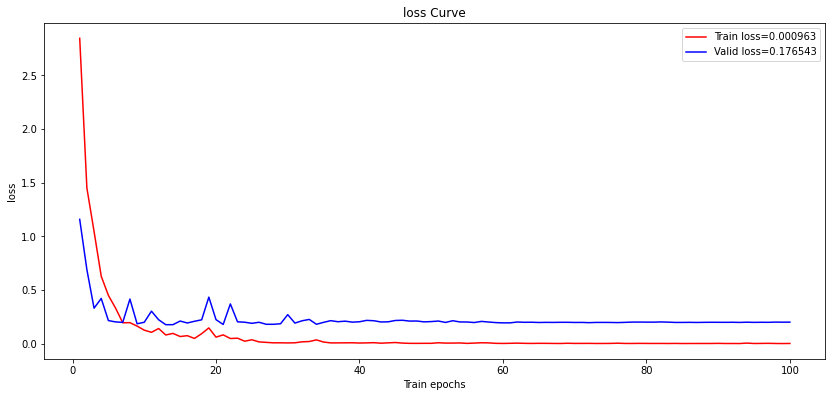

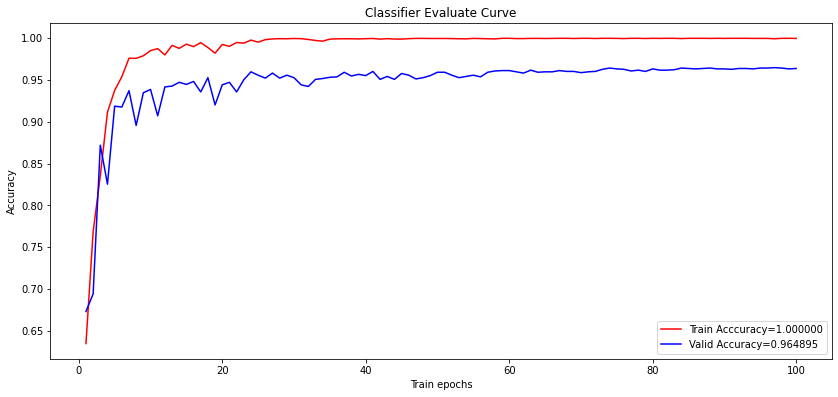

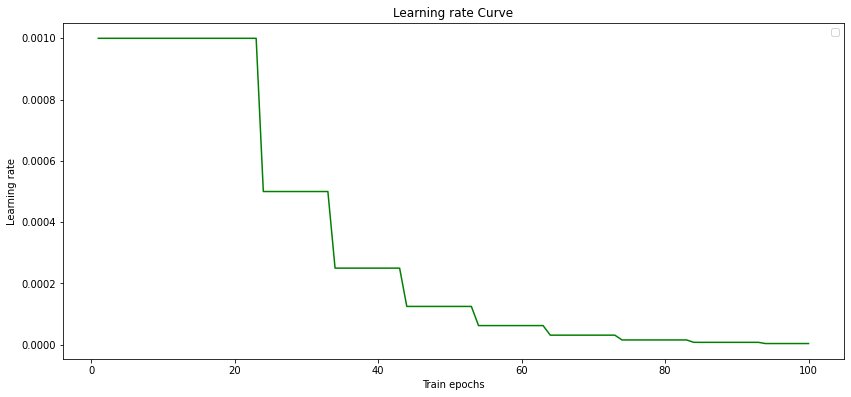

In [36]:
DisplayCurve(history=History,epoch=Epoch)

In [37]:
#计算训练集Accuracy
CerebriScan.evaluate(ImageDataset_Train,return_dict=True)

2025-08-28 00:40:41.839620: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_STRING
      type: DT_INT64
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 4655
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\024TensorSliceDataset:0"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_STRING
        }
      }
      args {
        

187/187 [==============================] - 111s 590ms/step - loss: 1.7375e-05 - accuracy: 1.0000


{'loss': 1.7375343304593116e-05, 'accuracy': 1.0}

In [39]:
#评估验证集Accuracy
CerebriScan.evaluate(ImageDataset_Valid,return_dict=True)

2025-08-28 00:43:17.502731: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_STRING
      type: DT_INT64
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 997
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\024TensorSliceDataset:6"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_STRING
        }
      }
      args {
        t

40/40 [==============================] - 24s 591ms/step - loss: 0.2019 - accuracy: 0.9629


{'loss': 0.2018575519323349, 'accuracy': 0.9628886580467224}

In [38]:
#计算测试集Accuracy
CerebriScan.evaluate(ImageDataset_Test,return_dict=True)

2025-08-28 00:42:41.989754: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_STRING
      type: DT_INT64
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 998
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\025TensorSliceDataset:12"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_STRING
        }
      }
      args {
        

40/40 [==============================] - 24s 595ms/step - loss: 0.3145 - accuracy: 0.9529


{'loss': 0.3144855499267578, 'accuracy': 0.9529058337211609}

In [ ]:
#使用评估函数评估模型性能
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score
def ShowDNNConfusionMatrix(Model,Dataset):
    #提取数据原始标签
    True_label=[]
    Proba=[]
    index_proba=[0,1,2]
    Predict_Label=[]
    for data,labelN in Dataset:
        Predict_Proba=Model.predict(data)
        for proba,label in zip(Predict_Proba,labelN):
            True_label.append(label)
            index=np.argmax(proba)
            label=index_proba[index]
            Predict_Label.append(label)
    Label=np.array(True_label)
    PredictLabel=np.array(Predict_Label)
    TestPrecision=precision_score(Label,PredictLabel,average='micro')
    TestRecall=recall_score(Label,PredictLabel,average='micro')
    TestF1=f1_score(Label,PredictLabel,average='micro')
    TestAccuracy=accuracy_score(Label,PredictLabel)
    print('模型测试集Precision:{0},Recall:{1},F1_score:{2},Accuracy:{3}'.format(TestPrecision,TestRecall,TestF1,TestAccuracy))
    print('-------------------数据集混淆举证-------------------')
    ConfusionMatrix_result=confusion_matrix(Label,PredictLabel,labels=[0,1,2])    #计算混淆举证
    Display_ConfusionMatrix=ConfusionMatrixDisplay(ConfusionMatrix_result,display_labels=['Normal','Ischemia','Bleeding'])
    Display_ConfusionMatrix.plot(include_values=True, cmap='viridis', xticks_rotation='horizontal', values_format='d', ax=None)
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
#训练集
ShowDNNConfusionMatrix(Model=CerebriScan,Dataset=ImageDataset_Train)

In [ ]:
#验证集
ShowDNNConfusionMatrix(Model=CerebriScan,Dataset=ImageDataset_Valid)

In [ ]:
#测试集
ShowDNNConfusionMatrix(Model=CerebriScan,Dataset=ImageDataset_Test)

In [ ]:
from sklearn.metrics import classification_report
from scipy.stats import chi2_contingency
from pandas import DataFrame
def ClassReport_X2(Model,Dataset):
    #提取数据原始标签
    True_label=[]
    Proba=[]
    index_proba=[0,1,2]
    Predict_Label=[]
    for data,labelN in Dataset:
        Predict_Proba=Model.predict(data)
        for proba,label in zip(Predict_Proba,labelN):
            True_label.append(label)
            index=np.argmax(proba)
            label=index_proba[index]
            Predict_Label.append(label)
    Label=np.array(True_label)
    PredictLabel=np.array(Predict_Label)
    print('-------------------数据集分类报告-------------------')
    print(classification_report(Label,PredictLabel,target_names=['Normal','Ischemia','Bleeding']))
    contingency_table = pd.crosstab(Label,PredictLabel, rownames=['True Label'], colnames=['Predict Label'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print('-------------------预测标签与真实标签卡方检验结果-------------------')
    print('卡方值为:{0},p值为:{1},自由度为:{2}'.format(chi2,p_value,dof))
    print('-------------------列联表-------------------')
    return DataFrame(contingency_table)

In [ ]:
#训练集
TrainDE=ClassReport_X2(Model=CerebriScan,Dataset=ImageDataset_Train)

In [ ]:
#验证集
ValidDE=ClassReport_X2(Model=CerebriScan,Dataset=ImageDataset_Valid)

In [ ]:
#测试集
TestDE=ClassReport_X2(Model=CerebriScan_StrokeCT,Dataset=ImageDataset_Test)